In [13]:
# Controlling cpu usage
import os
os.environ["NUMBA_NUM_THREADS"] = "6"
os.environ["OMP_NUM_THREADS"] = "6"
os.environ["MKL_NUM_THREADS"] = "6"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
import scanpy as sc
import anndata as ad
import numpy as np

In [ ]:
# Use the raw data for evaluation
brain_vascular = sc.read_h5ad("../brain_vascular.h5ad")
adata = brain_vascular.raw.to_adata()

# Adding mitochondrial gene annotation
adata.var["mt"] = adata.var["feature_name"].str.upper().str.startswith("MT-")
# Calculating QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True
)

adata_qc = adata[
    (adata.obs["n_genes_by_counts"] > 300) &
    (adata.obs["n_genes_by_counts"] < 8000) &
    (adata.obs["total_counts"] < 55000) &
    (adata.obs["pct_counts_mt"] < 15),
    :
].copy()

In [ ]:
# Ensure var names are not Ensemble IDs but gene names
adata_qc.var_names = adata_qc.var["names"]
adata_qc.write_h5ad("../metrics/UCE/input/adata_qc.h5ad")

In [ ]:
# Run UCE prediction (embeddings extraction)
python ../models/UCE/eval_single_anndata.py \
    --adata_path ../metrics/UCE/input/adata_qc.h5ad \ # input adata path
    --dir ../metrics/UCE/ \ # output dir
    --species human \
    --batch_size 100 

In [14]:
from emb_eva import evaluate_embeddings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

import pandas as pd

Embeddings Evaluation

In [ ]:
adata_emb = sc.read_h5ad("../metrics/UCE/UCE_embs_adata.h5ad")
label_col = "author_cell_type"

# Prepare embedding data for evaluation
X = adata_emb.obsm["X_uce"]
y = adata_emb.obs[label_col]

In [7]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [ ]:
# Evaluate embeddings with logistic regression classifier
results = []
result_logreg, y_pred_logreg, clf_logreg = evaluate_embeddings(
    X_train_emb=X_train,
    y_train=y_train,
    X_test_emb=X_test,
    y_test=y_test,
    model_name="Geneformer",
    classifier="logreg",
    random_state=42
)
results.append(result_logreg)

benchmark_df = pd.DataFrame(results)

/data/slurm/huangjr/envs/scInterBrain/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=4', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [9]:
benchmark_df

,model,classifier,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,n_train,n_test,embedding_dim
0,Geneformer,logreg,0.94878,0.949209,0.955477,0.952037,0.949411,0.94878,0.948924,49197,12300,1280


In [10]:
# Classification report
report = classification_report(
    y_test,
    y_pred_logreg,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
report_df

,precision,recall,f1-score,support
Arterial,0.931010,0.932310,0.931660,1433.00000
Astrocyte,0.989130,0.978495,0.983784,279.00000
Capillary,0.884146,0.848505,0.865959,1538.00000
Excitatory_Neuron,0.981544,0.983193,0.982368,595.00000
Inhibitory_Neuron,0.965944,0.971963,0.968944,321.00000
Meningeal_Fibroblast,0.973948,0.977867,0.975904,497.00000
Microglia,0.988211,0.978184,0.983172,1971.00000
Oligodendrocyte,0.994774,0.988745,0.991750,1155.00000
Oligodendrocyte_Precursor_Cell,1.000000,0.973684,0.986667,114.00000
Pericyte,0.938911,0.957995,0.948357,738.00000


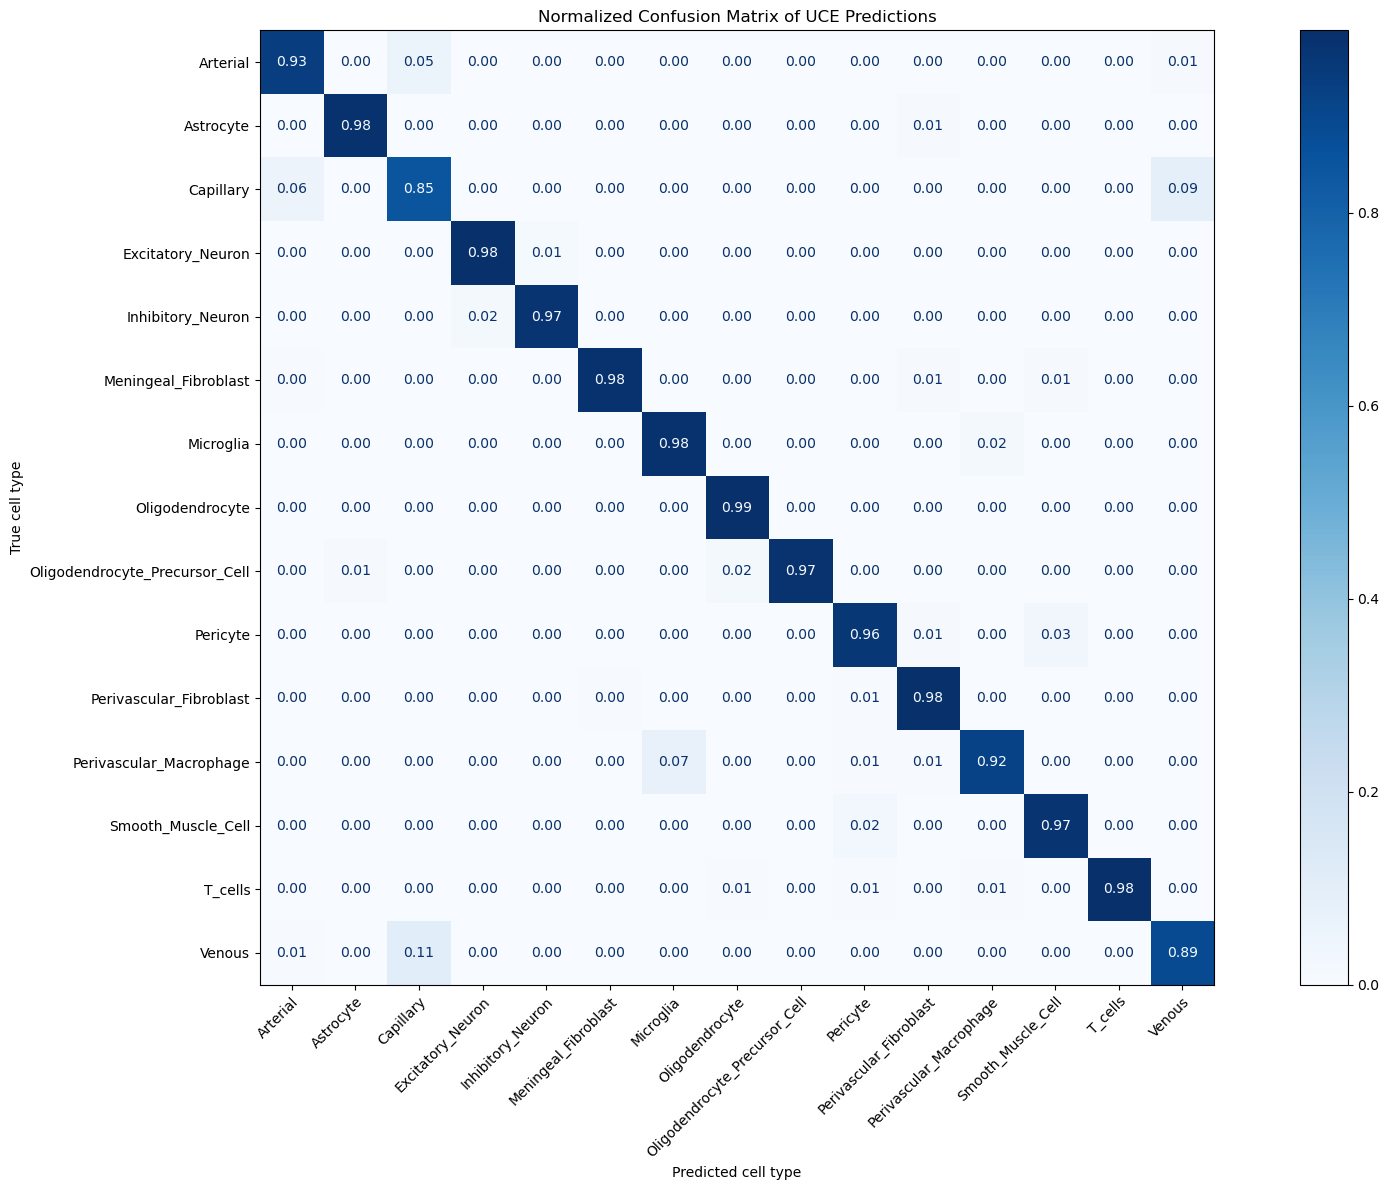

In [ ]:
# Confusion matrix
class_names = sorted(pd.Series(y_test).unique())

# Normalized confusion matrix
cm_norm = confusion_matrix(
    y_test,
    y_pred_logreg,
    labels=class_names,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(18, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format=".2f"
)

ax.set_title("Normalized Confusion Matrix of UCE Predictions")
ax.set_xlabel("Predicted cell type")
ax.set_ylabel("True cell type")

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
    label.set_rotation_mode("anchor")

plt.tight_layout()
plt.savefig("../metrics/UCE_conf_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
